# SOB4ES - Modelo Random Forest
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo Random Forest.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda aleatoria de hiperparametros.
4. Validacion cruzada: evaluacion de robustez.
5. Explicabilidad (SHAP): analisis de importancia de variables.
6. Produccion: entrenamiento del ensamble final y exportacion.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno


In [9]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

import itertools
from matplotlib.colors import LinearSegmentedColormap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import shap
import matplotlib.pyplot as plt

# ignoramos los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('output/var/').mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon 
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}
# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [10]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [11]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros de `RandomForestRegressor`. La busqueda se ejecuta exclusivamente sobre `X_train`.

**A diferencia de un enfoque de "target de referencia", aqui se ejecuta una busqueda independiente para CADA uno de los 21 targets**, de modo que cada variable objetivo obtiene su propia combinacion optima de hiperparametros (`RF_OPTIMAL_PARAMS_PER_TARGET`). Esto es mas costoso computacionalmente que ajustar un unico consenso, pero evita imponer a variables de dificil prediccion (p. ej. `coll_species_richness_z`) los hiperparametros optimizados para variables mas faciles (p. ej. `earthworm_richness_z`).

Principales hiperparametros explorados:
- `n_estimators`: numero de arboles en el bosque.
- `max_depth`: profundidad maxima de cada arbol.
- `min_samples_split` / `min_samples_leaf`: criterios de parada para la division de nodos.
- `max_features`: numero de variables consideradas en cada split.
- `bootstrap`: si se usa muestreo con reemplazamiento.

Para reducir el riesgo de sobreajuste con un dataset pequeño (~300 muestras), el grid se restringe: `max_depth` maximo 20, `min_samples_leaf` minimo 2, forzando `bootstrap=True` para mayor variabilidad entre arboles.


Iniciando busqueda de hiperparametros (Tuning) para cada target...
[ 1/21] Buscando hiperparametros para: nematode_shannon_z
         R2: 0.2036  |  tiempo: 3.4s
[ 2/21] Buscando hiperparametros para: macro_shannon_z
         R2: 0.2597  |  tiempo: 3.4s
[ 3/21] Buscando hiperparametros para: earthworm_shannon_z
         R2: 0.4538  |  tiempo: 3.4s
[ 4/21] Buscando hiperparametros para: orib_shannon_z
         R2: 0.0932  |  tiempo: 3.4s
[ 5/21] Buscando hiperparametros para: meso_shannon_z
         R2: 0.1026  |  tiempo: 3.4s
[ 6/21] Buscando hiperparametros para: coll_shannon_z
         R2: 0.2113  |  tiempo: 3.4s
[ 7/21] Buscando hiperparametros para: bac_shannon_z
         R2: 0.1021  |  tiempo: 3.4s
[ 8/21] Buscando hiperparametros para: fun_shannon_z
         R2: 0.0122  |  tiempo: 3.4s
[ 9/21] Buscando hiperparametros para: euk_shannon_z
         R2: 0.1776  |  tiempo: 3.4s
[10/21] Buscando hiperparametros para: oomy_shannon_z
         R2: 0.1419  |  tiempo: 3.3s
[11/21] Buscando

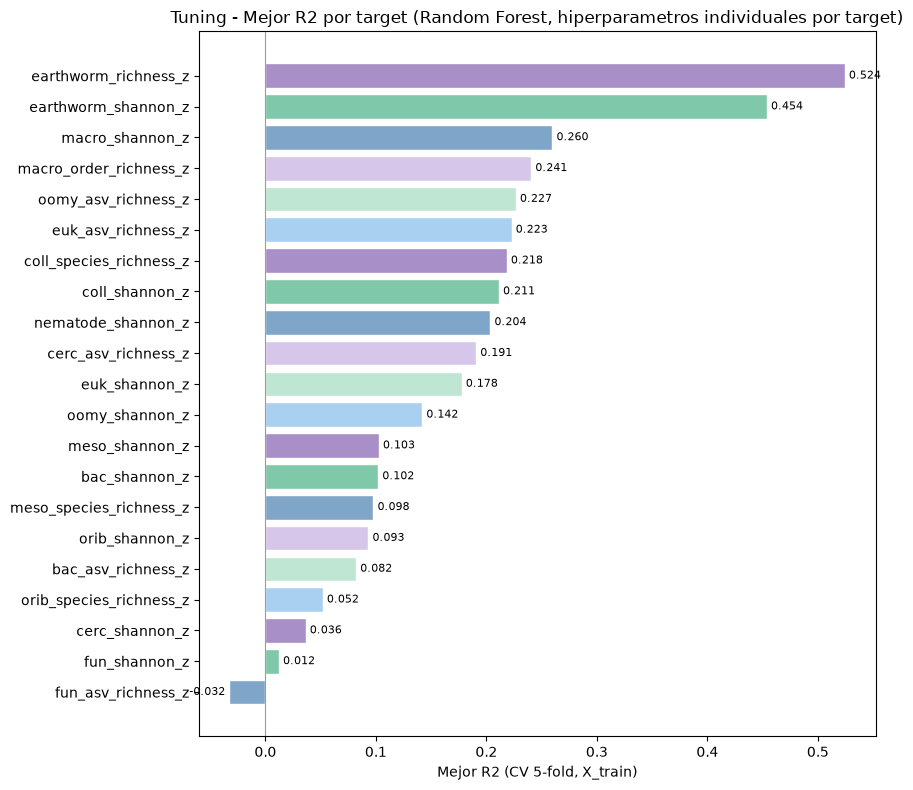

In [12]:
print('Iniciando busqueda de hiperparametros (Tuning) para cada target...')

param_grid = {
'n_estimators':      [100, 150, 200],
    'max_depth':         [3, 4, 5],
    'min_samples_leaf':  [8, 12, 16],
    'min_samples_split': [15, 20, 25],
    'max_features':      ['sqrt', 0.2, 0.3],
    'ccp_alpha':         [0.005, 0.01, 0.02],
    'bootstrap':         [True],
    'random_state':      [42]
}

resultados_tuning = {}
RF_OPTIMAL_PARAMS_PER_TARGET = {}
start_total = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    y_prueba = y_train[target_col].values
    t0 = time.time()
    print(f'[{idx:2d}/{len(TARGETS)}] Buscando hiperparametros para: {target_col}')

    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_grid,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=42,
        n_jobs= N_JOBS
    )
    buscador.fit(X_train, y_prueba)
    elapsed = time.time() - t0

    mejores_params = dict(buscador.best_params_)
    mejores_params['n_jobs'] = -1

    resultados_tuning[target_col] = {
        'params': mejores_params,
        'r2':     buscador.best_score_,
    }
    RF_OPTIMAL_PARAMS_PER_TARGET[target_col] = mejores_params

    print(f'         R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f}s')

print(f'\nBusqueda de hiperparametros completada en {(time.time() - start_total)/60:.1f} minutos...')

# Grafico: mejor R2 de tuning obtenido para cada uno de los 21 targets
r2_tuning_por_target = pd.Series({t: v['r2'] for t, v in resultados_tuning.items()}).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
_bars = ax.barh(r2_tuning_por_target.index, r2_tuning_por_target.values,
                 color=palette_cycle(len(r2_tuning_por_target)), edgecolor='white')
ax.bar_label(_bars, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xlabel('Mejor R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (Random Forest, hiperparametros individuales por target)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()


## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. Comparando el rendimiento en entrenamiento y en validacion se puede detectar sobreajuste, algo especialmente relevante en Random Forest dado que puede memorizar los datos de entrenamiento con facilidad.

In [13]:
print('Validacion cruzada repetida sobre X_train...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

resultados_cv_por_target = {}

# Impresión del encabezado de la tabla
header = f"{'TARGET':<26} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}"
print(header)
print('-' * len(header))

for target_col in TARGETS:
    y_prueba = y_train[target_col].values

    modelo_cv = RandomForestRegressor(
        **RF_OPTIMAL_PARAMS_PER_TARGET[target_col],
    )
    
    resultados = cross_validate(
        estimator=modelo_cv,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True,
        n_jobs=N_JOBS
    )

    r2_train   = np.mean(resultados['train_r2'])
    r2_cv      = np.mean(resultados['test_r2'])
    diferencia = r2_train - r2_cv

    resultados_cv_por_target[target_col] = {'train_r2': r2_train, 'cv_r2': r2_cv}

    estado = "Aviso: Posible sobreajuste" if diferencia > 0.15 else "OK"

    print(f"{target_col:<26} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida sobre X_train...

TARGET                     | TRAIN R2   | CV R2      | DIFF       | ESTADO
--------------------------------------------------------------------------
nematode_shannon_z         | 0.414      | 0.227      | 0.186      | Aviso: Posible sobreajuste
macro_shannon_z            | 0.518      | 0.262      | 0.256      | Aviso: Posible sobreajuste
earthworm_shannon_z        | 0.669      | 0.433      | 0.236      | Aviso: Posible sobreajuste
orib_shannon_z             | 0.371      | 0.097      | 0.274      | Aviso: Posible sobreajuste
meso_shannon_z             | 0.423      | 0.099      | 0.324      | Aviso: Posible sobreajuste
coll_shannon_z             | 0.481      | 0.177      | 0.304      | Aviso: Posible sobreajuste
bac_shannon_z              | 0.365      | 0.033      | 0.332      | Aviso: Posible sobreajuste
fun_shannon_z              | 0.375      | 0.038      | 0.337      | Aviso: Posible sobreajuste
euk_shannon_z              | 0.462      | 0.

## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (`TreeExplainer`) para analizar la importancia de las variables predictoras. `TreeExplainer` es compatible con `RandomForestRegressor` y calcula los valores de Shapley de forma exacta.

Interpretacion del grafico:
- Las variables se ordenan de mayor a menor importancia global.
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion.

Calculando valores SHAP sobre X_train para TODOS los targets...



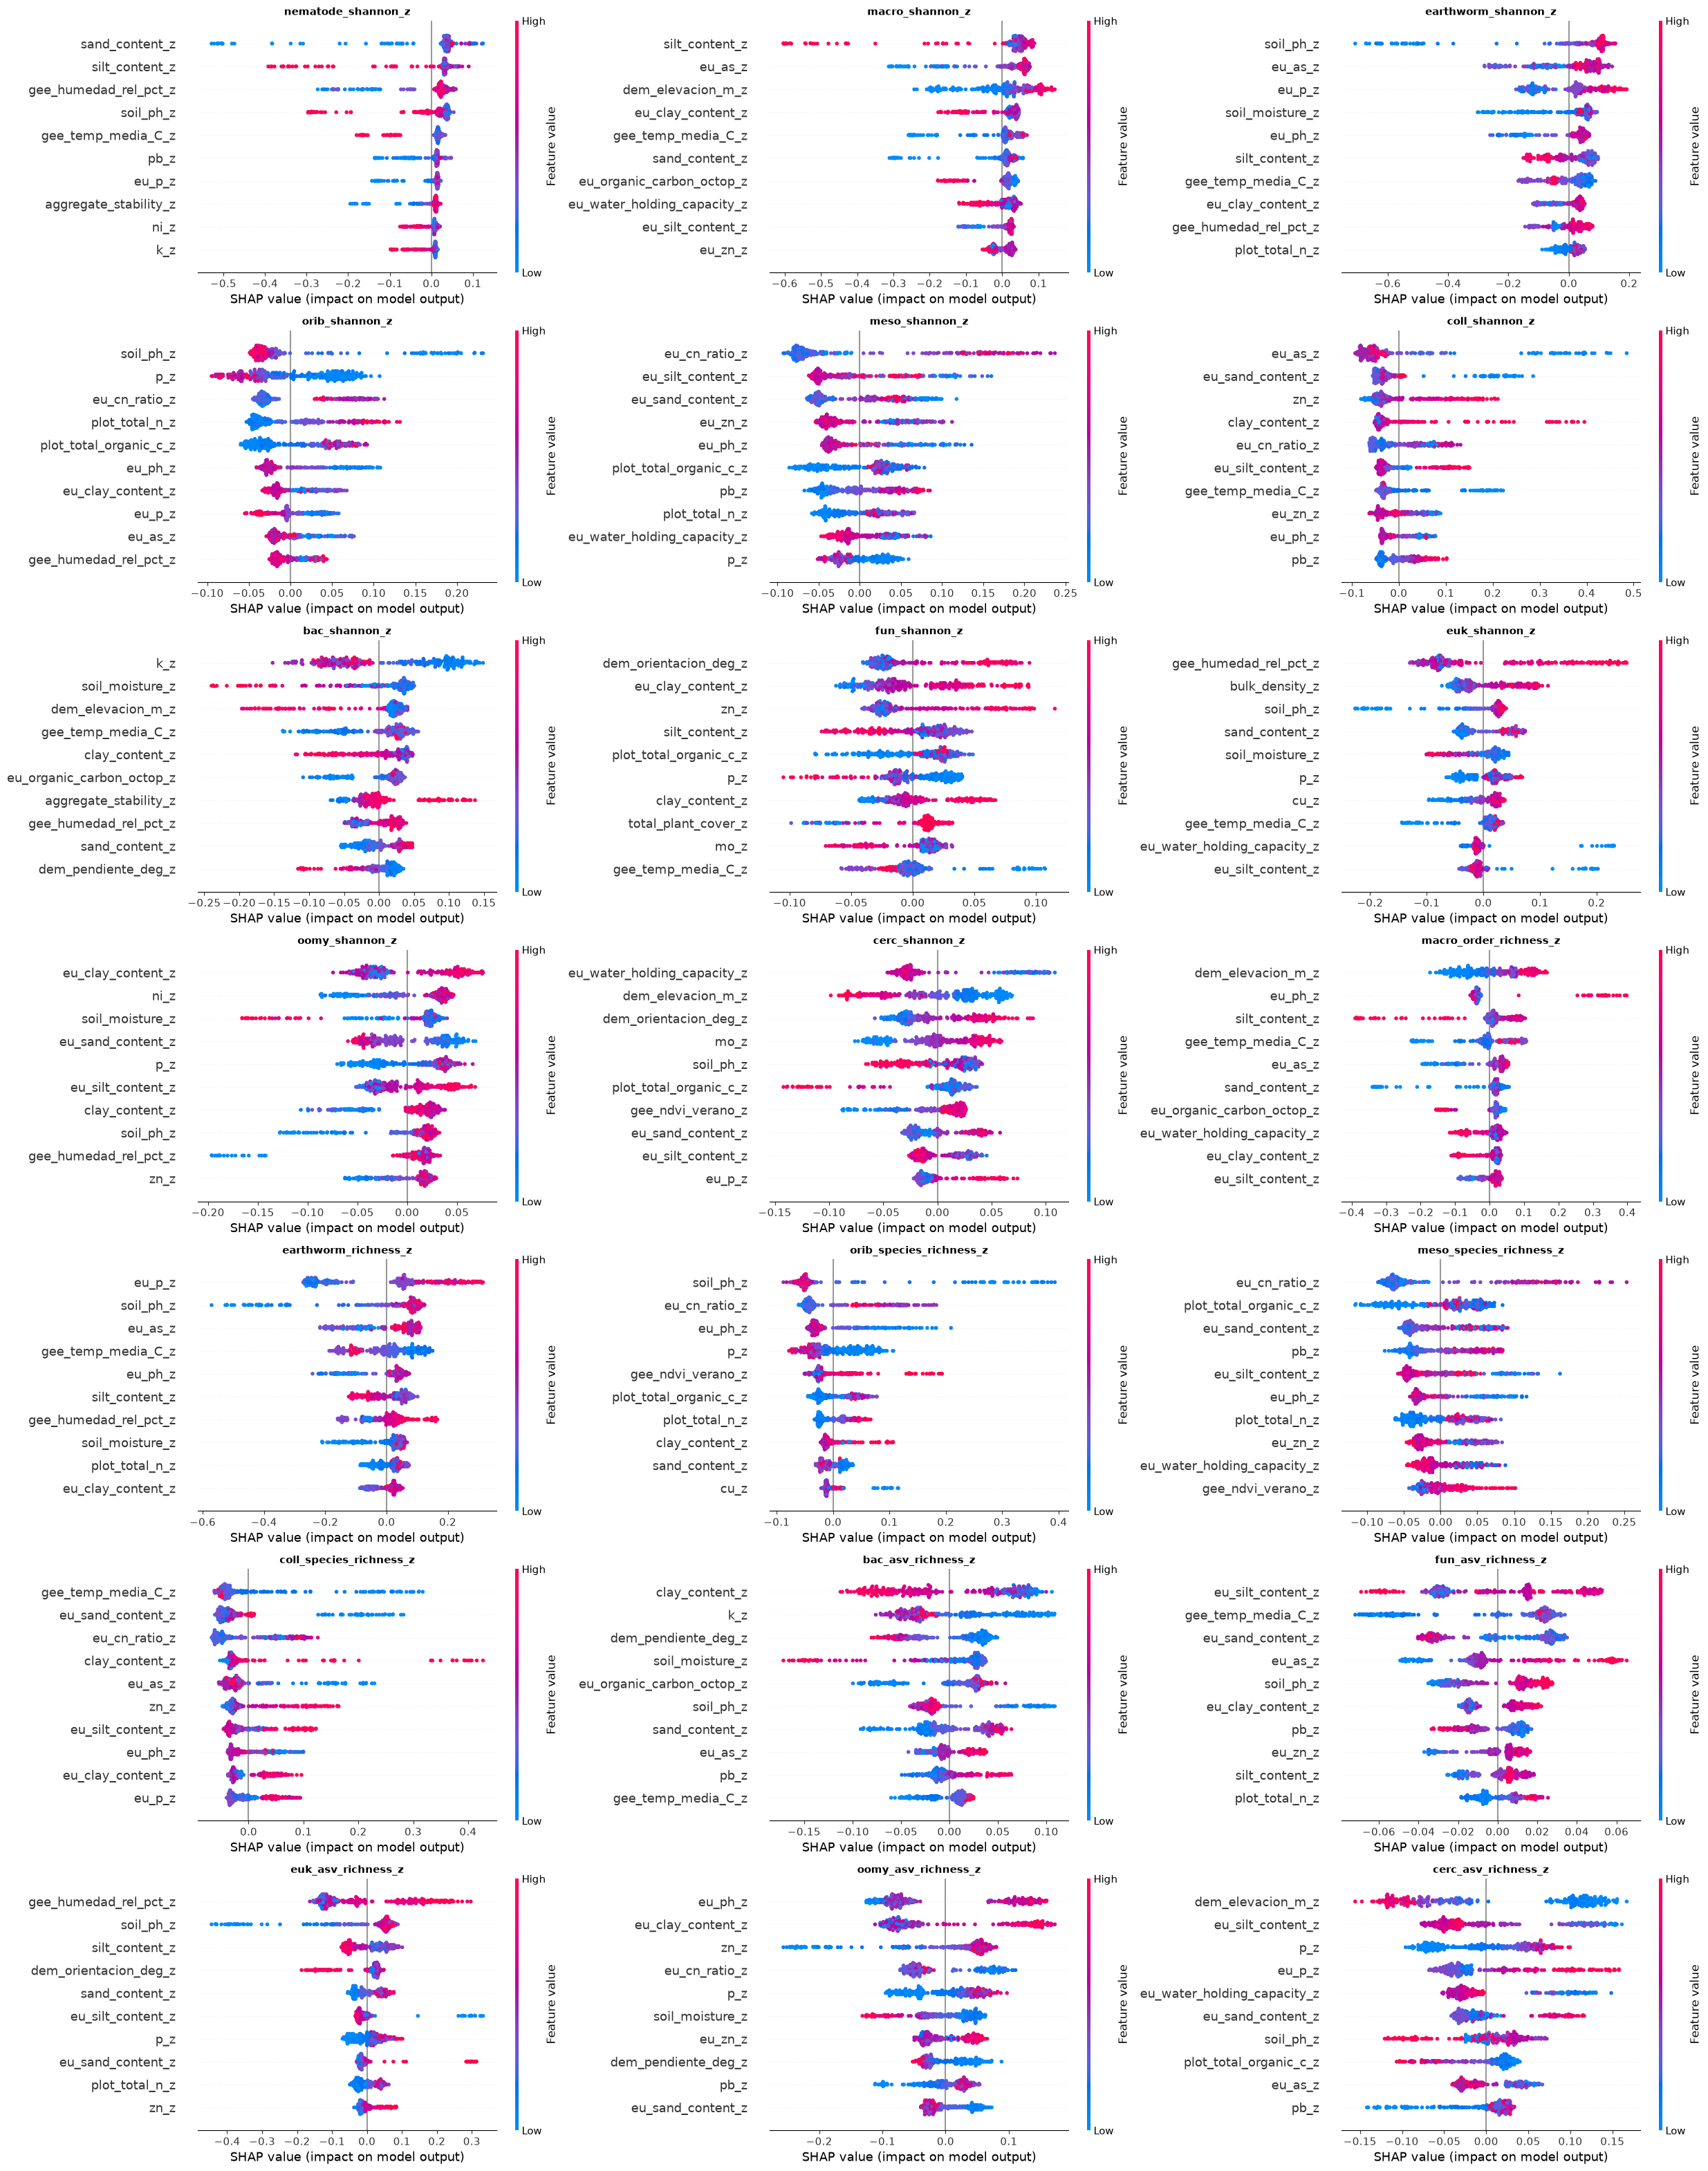


[INFO] Top 10 variables más importantes (global) exportadas a: './output/var/variables_mas_relevantes_rf.csv'

Top 10 variables MÁS importantes por SHAP (Promedio Global de Targets):
soil_ph_z                0.0391
eu_as_z                  0.0305
gee_temp_media_C_z       0.0301
eu_ph_z                  0.0299
gee_humedad_rel_pct_z    0.0288
eu_cn_ratio_z            0.0271
eu_clay_content_z        0.0253
eu_p_z                   0.0248
silt_content_z           0.0244
dem_elevacion_m_z        0.0240


Text(0, 0.5, '')

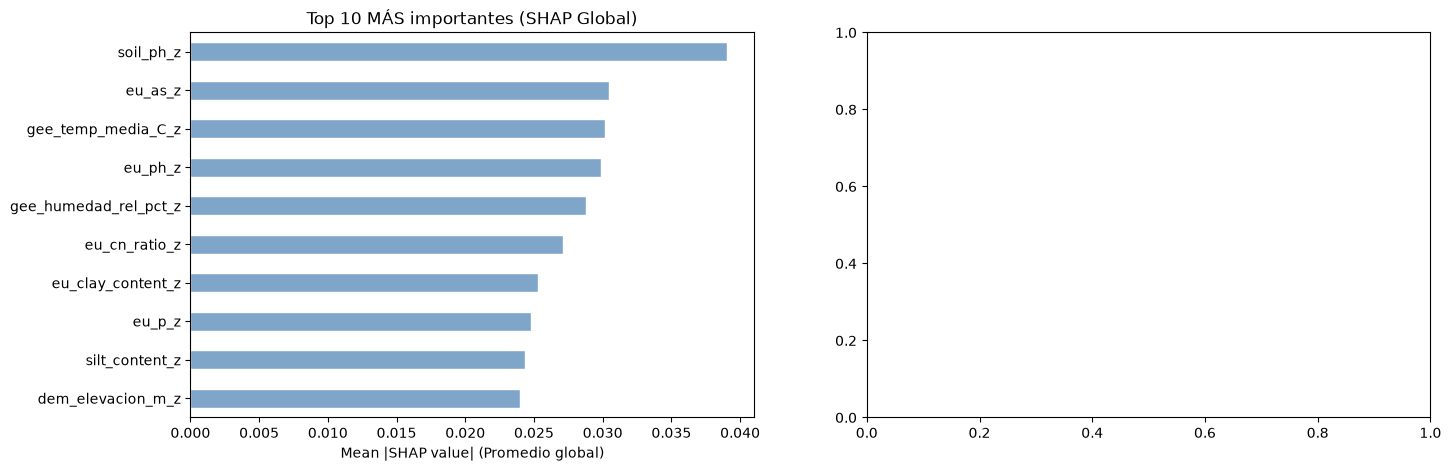

In [14]:
import math

print('Calculando valores SHAP sobre X_train para TODOS los targets...\n')

all_shap_means = []
n_targets = len(TARGETS)
n_cols = 3
n_rows = math.ceil(n_targets / n_cols)

# Crear el grid de subplots (5 columnas x N filas)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 4.5 * n_rows))
axes_flat = axes.flatten()

for i, tgt in enumerate(TARGETS):
    # Modelo específico para cada target
    modelo_shap = RandomForestRegressor(
        **RF_OPTIMAL_PARAMS_PER_TARGET[tgt],
    )
    modelo_shap.fit(X_train, y_train[tgt].values)
    
    # Cálculo de SHAP
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_train)
    
    # Renderizado en el subplot asignado dentro del grid
    plt.sca(axes_flat[i])
    shap.summary_plot(
        shap_values, 
        X_train, 
        plot_type='dot', 
        max_display=10, 
        show=False, 
        plot_size=None
    )
    axes_flat[i].set_title(tgt, fontsize=11, fontweight='bold')
    
    # Acumular la importancia absoluta media
    mean_abs_tgt = np.abs(shap_values).mean(axis=0)
    all_shap_means.append(mean_abs_tgt)

# Ocultar los subplots sobrantes en el grid
for j in range(n_targets, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

# Promedio global integrando todos los targets
global_shap_mean = np.mean(all_shap_means, axis=0)
shap_importance_series = pd.Series(global_shap_mean, index=FEATURES_AUTORIZADAS)

# Extraer Top 10 variables más y menos importantes a nivel global
top10_shap = shap_importance_series.nlargest(10)

# Exportación a archivos CSV
ruta_top_csv = './output/var/variables_mas_relevantes_rf.csv'

top10_shap.to_csv(ruta_top_csv, header=['mean_abs_shap_global'], index_label='variable')

print(f"\n[INFO] Top 10 variables más importantes (global) exportadas a: '{ruta_top_csv}'")

print('\nTop 10 variables MÁS importantes por SHAP (Promedio Global de Targets):')
print(top10_shap.round(4).to_string())


# Gráficos comparativos globales de barras
fig, axes_bar = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Más importantes
top10_shap.sort_values().plot(kind='barh', ax=axes_bar[0], color=PALETTE['blue'], edgecolor='white')
axes_bar[0].set_title('Top 10 MÁS importantes (SHAP Global)', fontsize=12)
axes_bar[0].set_xlabel('Mean |SHAP value| (Promedio global)')
axes_bar[0].set_ylabel('')

## 6.- Entrenamiento

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria. Esto complementa la aleatoridad intrinseca de Random Forest y reduce la varianza de las predicciones finales. Todos los modelos se guardan en disco en formato `.pkl`.

In [15]:
print('Entrenamiento de produccion (ensamble de 5 modelos por target, cada uno con sus propios')
print('hiperparametros optimos)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    for seed_id in range(NUM_MODELOS):
        params = RF_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        params['random_state'] = 42 + seed_id

        model = RandomForestRegressor(**params)
        model.fit(X_train, y)

        joblib.dump(model, os.path.join(MODELS_DIR, f'rf_prod_{target_col}_m{seed_id}.pkl'))

    print(f'  [{idx}/{len(TARGETS)}] {target_col:30} completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start)/60:.1f} minutos.')
print(f'Modelos guardados: {len(TARGETS) * NUM_MODELOS} ({NUM_MODELOS} por target).')
print('Cada target fue entrenado con su propia configuracion de hiperparametros.')


Entrenamiento de produccion (ensamble de 5 modelos por target, cada uno con sus propios
hiperparametros optimos)...
----------------------------------------------------------------------
  [1/21] nematode_shannon_z             completado (0.4s)
  [2/21] macro_shannon_z                completado (0.6s)
  [3/21] earthworm_shannon_z            completado (0.6s)
  [4/21] orib_shannon_z                 completado (0.8s)
  [5/21] meso_shannon_z                 completado (0.9s)
  [6/21] coll_shannon_z                 completado (0.6s)
  [7/21] bac_shannon_z                  completado (0.6s)
  [8/21] fun_shannon_z                  completado (0.6s)
  [9/21] euk_shannon_z                  completado (0.8s)
  [10/21] oomy_shannon_z                 completado (0.4s)
  [11/21] cerc_shannon_z                 completado (0.6s)
  [12/21] macro_order_richness_z         completado (0.8s)
  [13/21] earthworm_richness_z           completado (0.6s)
  [14/21] orib_species_richness_z        completado (0.

In [ ]:
# PRUEBA 3 - Barrido de random_state (0-100)

RANDOM_STATES = range(0, 101)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_rf')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    fila = {'random_state': rs}

    for target_col in TARGETS:
        params = RF_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        params['random_state'] = rs   # fuerza explícitamente el rs del barrido

        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train[target_col].values)

        y_pred = model.predict(X_eval)
        y_true = y_eval[target_col].values

        fila[f'{target_col}_r2']   = r2_score(y_true, y_pred)
        fila[f'{target_col}_rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        fila[f'{target_col}_mae']  = mean_absolute_error(y_true, y_pred)

        joblib.dump(model, os.path.join(dir_barrido, f'rf_prod_{target_col}_rs{rs}.pkl'))

    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_rf = pd.DataFrame(resultados_rs)
df_barrido_rf.to_csv(os.path.join(dir_barrido, 'rf_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')

TypeError: RandomForestRegressor.__init__() got an unexpected keyword argument 'nematode_shannon_z'

## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

In [ ]:
# Evaluacion final sobre todos los targets

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    preds_eval = []
    for seed_id in range(5):
        ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)

# Smoke test con datos reales
# Se prueban los targets representativos

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)
        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        votos = []
        for seed_id in range(5):
            ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {seed_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        consenso = np.mean(votos, axis=0)
        print('  ' + '-' * 63)
        print('  Resultados detallados:')
        print('  ' + '-' * 63)
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error: {abs(pred_val-real_val):.4f}')

    print('\nSmoke test superado. El pipeline funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'rf_prod_{tgt}_m{i}.pkl')).predict(X_eval)
             for i in range(NUM_MODELOS)]
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color=PALETTE['blue'])
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - Random Forest (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()